# Static linear encoding and Information Imbalance

This notebook combines bidirectional static linear encoding with Information Imbalance (II) at one neural-response timepoint. It performs the following operations:

1. Predict model features from the selected neural population response (`neural -> model`).
2. Predict the neural population response from model features (`model -> neural`).
3. Compute per-output $R^2$ for both projections.
4. Compute static II between the **predicted neural** and **predicted model** spaces.

By default, the projections are fitted and evaluated on all images (`use_cv=False`). Setting `use_cv=True` produces out-of-fold predictions, and II is then computed only from those out-of-fold predictions.

In [2]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from torchvision.datasets import ImageFolder
from sklearn.decomposition import PCA

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.static_encoding import (
    compute_static_prediction_II,
    fit_static_projection,
)
from project_specific_utils.dataloader import (
    load_img_natraster,
    map_image_order_from_ann_to_monkey,
)
from useful_stuff.general_utils.regression import linear_encoding


In [11]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    new_fs: int = 100
    neural_timepoint_idx: int = 17
    pca_comp = 300
    # Static model-feature parameters.
    model_name: str = "vit_l_16"
    img_size: int = 384
    layer_name: str = "blocks.1.mlp.fc2"
    pooling: str = "mean"

    # Linear encoding parameters. CV is deliberately disabled for this run.
    regression_type: str = "lr"
    use_cv: bool = False
    cv_type: str = "same"
    n_splits: int = 5
    shuffle: bool = True
    random_seed: int = 0
    alpha_min: float = 1e-6
    alpha_max: float = 1e3
    n_alphas: int = 10

    # Static Information Imbalance parameters.
    neural_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    k: int = 10
# EOC


cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', new_fs=100, neural_timepoint_idx=17, model_name='vit_l_16', img_size=384, layer_name='blocks.1.mlp.fc2', pooling='mean', regression_type='lr', use_cv=False, cv_type='same', n_splits=5, shuffle=True, random_seed=0, alpha_min=1e-06, alpha_max=1000.0, n_alphas=10, neural_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', k=10)

## Load and align the static spaces

The neural raster is shaped `(neurons, timepoints, images)`. Model features are reordered to the monkey image-presentation order and remain shaped `(model features, images)`.

In [12]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    is_valid_file=lambda path: not path.endswith("Thumbs.db"),
    allow_empty=True,
)
idx_ord = map_image_order_from_ann_to_monkey(
    paths, cfg.monkey_name, cfg.date, dataset
)

features_path = (
    Path(paths["data_path"])
    / "models"
    / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}"
        f"_features_{cfg.pooling}pool.npz"
    )
)
model_features = np.load(features_path)["arr_0"][:, idx_ord]
if cfg.pca_comp is not None:
    pca_obj = PCA(n_components=cfg.pca_comp)
    model_features = pca_obj.fit_transform(model_features.T)
    model_features = model_features.T

    
raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, images), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3
if model_features.ndim != 2:
    raise ValueError(
        "Expected model data with shape (features, images), "
        f"received {model_features.shape}."
    )
# end if model_features.ndim != 2
if raster_array.shape[2] != model_features.shape[1]:
    raise ValueError(
        "Neural and model spaces have different image counts: "
        f"{raster_array.shape[2]} and {model_features.shape[1]}."
    )
# end if raster_array.shape[2] != model_features.shape[1]

print(f"Neural raster: {raster_array.shape}")
print(f"Aligned model features: {model_features.shape}")
print(f"Model features loaded from: {features_path}")


Neural raster: (25, 30, 776)
Aligned model features: (300, 776)
Model features loaded from: /Users/tizianocausin/metrics_II_local/models/talia_20each_tizi_vit_l_16_384_blocks.1.mlp.fc2_features_meanpool.npz


In [13]:
n_timepoints = raster_array.shape[1]
if not -n_timepoints <= cfg.neural_timepoint_idx < n_timepoints:
    raise IndexError(
        f"neural_timepoint_idx={cfg.neural_timepoint_idx} is outside a response "
        f"with {n_timepoints} timepoints."
    )
# end if not -n_timepoints <= cfg.neural_timepoint_idx < n_timepoints

# Convert a possible negative index to the corresponding non-negative index.
timepoint_idx = cfg.neural_timepoint_idx % n_timepoints
neural_response = raster_array[:, timepoint_idx, :]
time_from_raster_start_s = timepoint_idx / raster.get_fs()

print(
    f"Selected neural timepoint {timepoint_idx}/{n_timepoints - 1} "
    f"({time_from_raster_start_s:.3f} s from raster start)."
)
print(f"Static neural response: {neural_response.shape}")


Selected neural timepoint 17/29 (0.170 s from raster start).
Static neural response: (25, 776)


## Fit the two static linear projections

`predicted_model` is generated from the neural response, while `predicted_neural` is generated from the model features. The default scores are descriptive in-sample $R^2$ values. With `cfg.use_cv=True`, the helper instead assembles predictions from held-out folds before computing $R^2$.

In [14]:
if cfg.regression_type not in {"lr", "ridge", "lasso", "en"}:
    raise ValueError(f"Unsupported regression_type: {cfg.regression_type}")
# end if cfg.regression_type not in supported types
if cfg.use_cv and cfg.cv_type not in {"loo", "kf"}:
    raise ValueError("Use 'loo' or 'kf' when use_cv=True.")
# end if cfg.use_cv and cfg.cv_type not in supported types

# The existing KFold implementation draws from NumPy's global random state.
alphas = np.logspace(
    np.log10(cfg.alpha_min), np.log10(cfg.alpha_max), cfg.n_alphas
)
active_cv_type = cfg.cv_type if cfg.use_cv else "same"

neural_to_model_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    alphas=alphas,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)
model_to_neural_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    alphas=alphas,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)

# Reset the seed before each direction so future CV uses identical folds.
np.random.seed(cfg.random_seed)
# neural -> model: each model feature is one regression target.
predicted_model, model_r2 = fit_static_projection(
    neural_response,
    model_features,
    neural_to_model_encoding,
    use_cv=cfg.use_cv,
)

np.random.seed(cfg.random_seed)
# model -> neural: each neuron is one regression target.
predicted_neural, neural_r2 = fit_static_projection(
    model_features,
    neural_response,
    model_to_neural_encoding,
    use_cv=cfg.use_cv,
)


In [15]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(
    "neural -> model: "
    f"mean R^2={np.nanmean(model_r2):.4f}, "
    f"median R^2={np.nanmedian(model_r2):.4f}, "
    f"prediction shape={predicted_model.shape}"
)
print(
    "model -> neural: "
    f"mean R^2={np.nanmean(neural_r2):.4f}, "
    f"median R^2={np.nanmedian(neural_r2):.4f}, "
    f"prediction shape={predicted_neural.shape}"
)
print(
    "Full-data weight shapes: "
    f"neural -> model {neural_to_model_encoding.get_weights().shape}, "
    f"model -> neural {model_to_neural_encoding.get_weights().shape}"
)

# A high-dimensional in-sample projection can interpolate the neural targets.
if not cfg.use_cv and model_features.shape[0] >= model_features.shape[1]:
    print(
        "Note: model features outnumber images, so the in-sample model -> neural "
        "R² can be saturated. Enable CV for a generalization estimate."
    )
# end if not cfg.use_cv and model_features.shape[0] >= model_features.shape[1]


Encoding mode: in-sample
neural -> model: mean R^2=0.0350, median R^2=0.0331, prediction shape=(300, 776)
model -> neural: mean R^2=0.4607, median R^2=0.4622, prediction shape=(25, 776)
Full-data weight shapes: neural -> model (300, 25), model -> neural (25, 300)


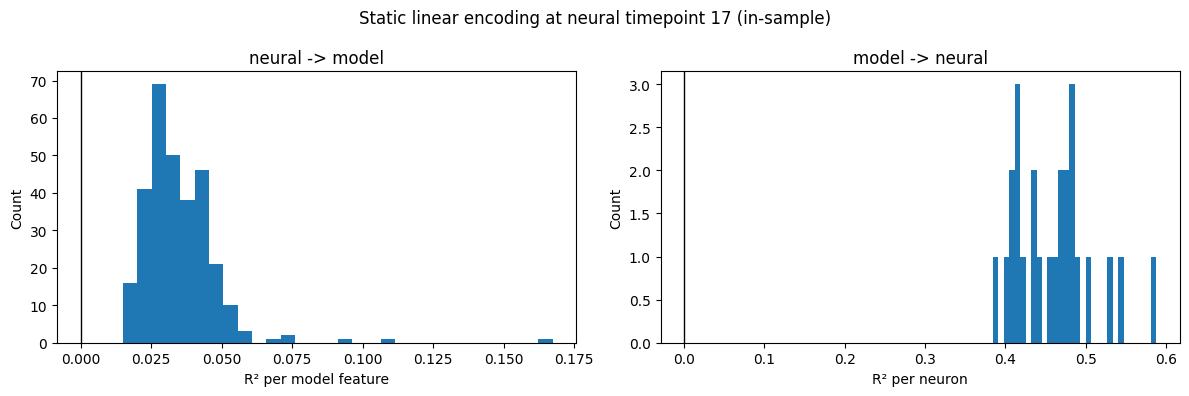

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(model_r2[np.isfinite(model_r2)], bins=30)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("neural -> model")
axes[0].set_xlabel("R² per model feature")
axes[0].set_ylabel("Count")

axes[1].hist(neural_r2[np.isfinite(neural_r2)], bins=30)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("model -> neural")
axes[1].set_xlabel("R² per neuron")
axes[1].set_ylabel("Count")

fig.suptitle(
    f"Static linear encoding at neural timepoint {timepoint_idx} ({encoding_mode})"
)
fig.tight_layout()


## Information Imbalance between the predicted spaces

Here `signal` means the predicted neural space and `model` means the predicted model space. Therefore, static II `A2B` is **predicted neural -> predicted model**, and `B2A` is **predicted model -> predicted neural**.

In [17]:
ii_obj, predicted_neural_to_model_II, predicted_model_to_neural_II = (
    compute_static_prediction_II(
        predicted_neural=predicted_neural,
        predicted_model=predicted_model,
        neural_RDM_metric=cfg.neural_RDM_metric,
        model_RDM_metric=cfg.model_RDM_metric,
        k=cfg.k,
    )
)

print(
    "predicted neural -> predicted model: "
    f"II={predicted_neural_to_model_II:.6f}"
)
print(
    "predicted model -> predicted neural: "
    f"II={predicted_model_to_neural_II:.6f}"
)


predicted neural -> predicted model: II=0.613995
predicted model -> predicted neural: II=0.512948


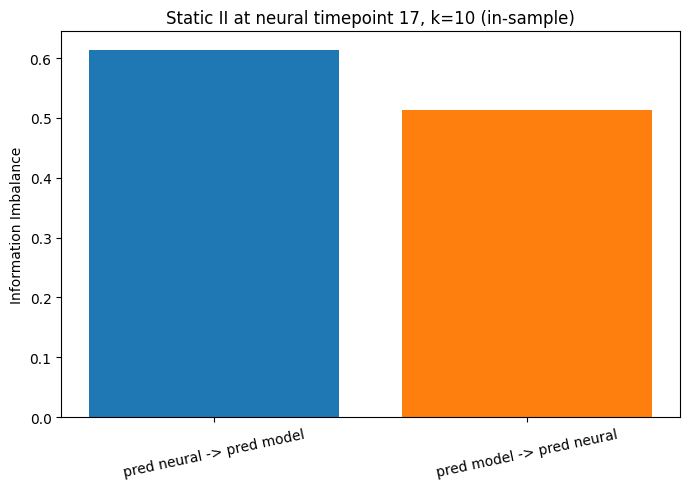

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
directions = ["pred neural -> pred model", "pred model -> pred neural"]
ii_values = [predicted_neural_to_model_II, predicted_model_to_neural_II]
ax.bar(directions, ii_values, color=["tab:blue", "tab:orange"])
ax.set_ylabel("Information Imbalance")
ax.set_title(
    f"Static II at neural timepoint {timepoint_idx}, k={cfg.k} ({encoding_mode})"
)
ax.tick_params(axis="x", rotation=12)
fig.tight_layout()
